# Load and stress test analysis (slide 9)

Analyses every JMeter run in `results/<model>/<test>/run<N>/` for the three candidate models:

| Test | Offered load | Requirement |
|---|---|---|
| `mixed` | 198 `POST /tickets`/h + 800 `GET /search`/h, 60 min | **R2** POST p95 ≤ 10 s, p99 ≤ 20 s, errors < 1% · **R3** search p95 ≤ 1 s, errors < 1% |
| `surge` | 334 `POST /tickets`/h, 60 min | **R1** achieved ≥ 327/h, errors < 1%, p95 in the last 15 min ≤ 1.5× the first 15 min |
| `stress` | `POST /tickets` stepped up every 15 min (tev1:4b only) | finds the throughput limit |

Each run folder holds `results.jtl` (every JMeter sample), `service.jsonl` (the service log), `cpu.csv`,
`loadgen.json` and `metadata.json`. JMeter samples and log lines are matched one-to-one by request id.

**Definitions used throughout** (the same as on slide 9):

- Latency is JMeter's `elapsed` (end to end, as the client sees it). Percentiles use the nearest-rank method.
- A run's window starts at its first sample. *Achieved* throughput counts successful responses that **completed**
  inside the 60-minute window, so work finished during the drain after the schedule ends does not count.
- Per configuration, the slide reports the **mean of the three runs' values, with the min–max across runs**.
  Percentiles are computed per run, never by pooling samples across runs.
- A requirement **passes only if all three runs meet it**.
- S is a model's mean single-request service time, taken from its accuracy run on the same machine
  (150 tickets sent one at a time, so no queueing).

In [ ]:
import glob
import json
import math
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "loadtest" else os.getcwd()
RESULTS = os.path.join(ROOT, "results")
OUT_DIR = os.path.join(ROOT, "loadtest", "analysis_output")
os.makedirs(OUT_DIR, exist_ok=True)

MODELS = {"tev1-4b": "tev1:4b", "clef-flash-9b": "clef-flash:9b", "qwen3.8-27b": "qwen3.8:27b"}
# One fixed colour per model, the same as in the accuracy notebook
MODEL_COLORS = {"tev1:4b": "#2a78d6", "clef-flash:9b": "#eb6834", "qwen3.8:27b": "#1baf7a"}
TEAL, AMBER, INK, MUTED, GRID = "#14838A", "#C8811A", "#1E2A35", "#5B6B7A", "#E4E9EE"

WINDOW_MIN = 60
THREAD_POOL = 40          # FastAPI/anyio default worker threads for sync endpoints (prediction B3)
OLLAMA_TIMEOUT_S = 600    # service's OLLAMA_TIMEOUT: returns 502 after this
JMETER_TIMEOUT_S = 650    # JMeter response timeout
PREDICTED_CEILING = 465   # tickets/h for tev1:4b, Requirements/prediction_record.md section 3

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10,
})
pd.set_option("display.max_colwidth", 80)


def nearest_rank(values, p):
    v = sorted(x for x in values if not pd.isna(x))
    return v[max(0, math.ceil(p / 100 * len(v)) - 1)] if v else np.nan


def read_json(path):
    with open(path, encoding="utf-8-sig") as f:
        return json.load(f)


def error_kind(code):
    code = str(code)
    if code == "502":
        return f"502: Ollama timeout ({OLLAMA_TIMEOUT_S} s)"
    if "SocketTimeoutException" in code:
        return f"JMeter timeout ({JMETER_TIMEOUT_S} s)"
    if "ConnectTimeoutException" in code:
        return "connect timeout"
    if "SocketException" in code:
        return "connection reset"
    return f"HTTP {code}"


def load_run(run_dir):
    jtl = pd.read_csv(os.path.join(run_dir, "results.jtl"))
    jtl["ok"] = jtl.success.astype(str).str.lower().eq("true")
    jtl["end"] = jtl.timeStamp + jtl.elapsed
    jtl["t_min"] = (jtl.timeStamp - jtl.timeStamp.min()) / 60_000
    with open(os.path.join(run_dir, "service.jsonl"), encoding="utf-8") as f:
        lines = [json.loads(line) for line in f]
    log = pd.DataFrame([r for r in lines if r.get("event") == "request"])
    cpu = pd.read_csv(os.path.join(run_dir, "cpu.csv"))
    num = cpu.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")
    cpu = pd.DataFrame({
        "total": num[[c for c in num if "_Total" in c]].sum(axis=1, min_count=1),
        "ollama_process": num[[c for c in num if "Process(ollama" in c]].sum(axis=1, min_count=1),
    })
    return {"jtl": jtl, "log": log, "cpu": cpu,
            "loadgen": read_json(os.path.join(run_dir, "loadgen.json")),
            "meta": read_json(os.path.join(run_dir, "metadata.json"))}


runs = {}  # (model, test, run) -> data, in MODELS order
for model_dir in MODELS:
    for test in ("mixed", "surge", "stress"):
        dirs = glob.glob(os.path.join(RESULTS, model_dir, test, "run*"))
        for d in sorted(dirs, key=lambda d: int(os.path.basename(d)[3:])):
            if os.path.exists(os.path.join(d, "results.jtl")):
                runs[(MODELS[model_dir], test, int(os.path.basename(d)[3:]))] = load_run(d)
print(f"Loaded {len(runs)} runs")


Loaded 19 runs


## 1. Service time S per model

From each model's accuracy run (same machine as the load tests). Utilisation at an arrival rate λ is
ρ = λ·S; the service can keep up only while ρ < 1, and capacity is about 1/S tickets per hour.

In [2]:
S = {}
rows = []
for model_dir, tag in MODELS.items():
    path = os.path.join(RESULTS, model_dir, "accuracy", "run1", "service.jsonl")
    with open(path, encoding="utf-8") as f:
        lat = [r["latency_ms"] / 1000 for r in map(json.loads, f)
               if str(r.get("request_id", "")).startswith("golden-") and r.get("status") == 200]
    S[tag] = np.mean(lat)
    rows.append({"model": tag, "tickets": len(lat), "S mean (s)": np.mean(lat), "p50 (s)": nearest_rank(lat, 50),
                 "capacity 1/S (/h)": 3600 / np.mean(lat),
                 "ρ at 198/h": 198 * np.mean(lat) / 3600, "ρ at 334/h": 334 * np.mean(lat) / 3600})
service_time = pd.DataFrame(rows)
service_time.round(2)


,model,tickets,S mean (s),p50 (s),capacity 1/S (/h),ρ at 198/h,ρ at 334/h
0,tev1:4b,150,5.41,5.32,664.82,0.30,0.50
1,clef-flash:9b,150,9.73,9.49,370.13,0.53,0.90
2,qwen3.8:27b,150,46.92,41.54,76.72,2.58,4.35


## 2. Run inventory and reconciliation

Every number must trace back to the logs. For each run: the model digest and SUT recorded at collection,
whether the code was committed, and how JMeter samples match service-log lines by request id.
*JMeter only* samples never reached the service (connection errors); *log only* lines are requests the
service handled but JMeter has no sample for.

In [3]:
rows = []
for (tag, test, run), r in runs.items():
    jtl, log, meta, lg = r["jtl"], r["log"], r["meta"], r["loadgen"]
    service_ids = set(log.request_id[log.request_id.str.match(r"^[ts]-")])
    jtl_ids = set(jtl.req_id.dropna())
    rows.append({
        "model": tag, "test": test, "run": run,
        "JMeter samples": len(jtl), "matched": len(jtl_ids & service_ids),
        "JMeter only": len(jtl_ids - service_ids), "log only": len(service_ids - jtl_ids),
        "digest": (meta.get("model_digest") or "")[:12], "SUT": meta.get("sut_hostname"),
        "git dirty": meta.get("git_dirty"), "HTTP RTT p50 (ms)": (lg.get("network_http_rtt") or {}).get("p50_ms"),
    })
inventory = pd.DataFrame(rows)
inventory


,model,test,run,JMeter samples,matched,JMeter only,log only,digest,SUT,git dirty,HTTP RTT p50 (ms)
0,tev1:4b,mixed,1,998,998,0,0,9b5bb969e46c,DESKTOP-PGFAHG3,True,144.7
1,tev1:4b,mixed,2,998,998,0,0,9b5bb969e46c,DESKTOP-PGFAHG3,True,146.7
2,tev1:4b,mixed,3,998,998,0,0,9b5bb969e46c,DESKTOP-PGFAHG3,True,146.3
3,tev1:4b,surge,1,334,334,0,0,9b5bb969e46c,DESKTOP-PGFAHG3,False,141.3
4,tev1:4b,surge,2,334,334,0,0,9b5bb969e46c,DESKTOP-PGFAHG3,False,144.1
5,tev1:4b,surge,3,334,334,0,0,9b5bb969e46c,DESKTOP-PGFAHG3,False,144.5
6,tev1:4b,stress,1,700,580,120,0,9b5bb969e46c,DESKTOP-PGFAHG3,False,151.7
7,clef-flash:9b,mixed,1,998,998,0,0,9f4115499b98,DESKTOP-PGFAHG3,False,152.4
8,clef-flash:9b,mixed,2,998,997,1,0,9f4115499b98,DESKTOP-PGFAHG3,False,66.5
9,clef-flash:9b,mixed,3,998,991,7,0,9f4115499b98,DESKTOP-PGFAHG3,False,67.8


## 3. Per-run results

One row per run and endpoint. `drift` is p95 of tickets arriving in the last 15 minutes divided by p95 of
those arriving in the first 15 minutes (R1's "latency is not growing" check).

In [4]:
def endpoint_stats(g, t0, window_min=WINDOW_MIN):
    lat = (g.elapsed / 1000).tolist()
    done = g[g.ok & (g.end <= t0 + window_min * 60_000)]
    out = {"samples": len(g), "p50": nearest_rank(lat, 50), "p95": nearest_rank(lat, 95),
           "p99": nearest_rank(lat, 99), "max": max(lat),
           "achieved /h": len(done) * 60 / window_min, "errors %": 100 * (1 - g.ok.mean())}
    first = g[g.timeStamp < t0 + 15 * 60_000].elapsed / 1000
    last = g[g.timeStamp >= t0 + (window_min - 15) * 60_000].elapsed / 1000
    out["drift"] = nearest_rank(last, 95) / nearest_rank(first, 95)
    return out


rows = []
for (tag, test, run), r in runs.items():
    if test == "stress":
        continue
    jtl = r["jtl"]
    t0 = jtl.timeStamp.min()
    for label, g in jtl.groupby("label"):
        rows.append({"model": tag, "test": test, "run": run, "endpoint": label, **endpoint_stats(g, t0)})
per_run = pd.DataFrame(rows)
per_run.round(2)


,model,test,run,endpoint,samples,p50,p95,p99,max,achieved /h,errors %,drift
0,tev1:4b,mixed,1,GET /search,800,0.18,0.29,0.42,2.86,800.0,0.00,1.04
1,tev1:4b,mixed,1,POST /tickets,198,5.74,10.77,18.74,20.91,198.0,0.00,1.84
2,tev1:4b,mixed,2,GET /search,800,0.17,0.30,0.60,2.13,800.0,0.00,1.21
3,tev1:4b,mixed,2,POST /tickets,198,5.68,11.72,17.01,18.05,198.0,0.00,0.96
4,tev1:4b,mixed,3,GET /search,800,0.21,0.35,0.45,3.21,800.0,0.00,1.15
5,tev1:4b,mixed,3,POST /tickets,198,5.72,12.54,16.07,16.63,198.0,0.00,0.83
6,tev1:4b,surge,1,POST /tickets,334,7.15,18.05,23.41,27.63,332.0,0.60,1.47
7,tev1:4b,surge,2,POST /tickets,334,7.14,18.55,24.08,26.10,334.0,0.00,1.53
8,tev1:4b,surge,3,POST /tickets,334,7.05,17.26,23.55,30.72,333.0,0.30,1.17
9,clef-flash:9b,mixed,1,GET /search,800,0.21,0.34,0.49,3.23,800.0,0.00,1.24


### Errors by cause

`502` is the service giving up on Ollama after 600 s. `JMeter timeout` is JMeter giving up after 650 s.
Connection resets and connect timeouts never reached the service (see *JMeter only* above).

In [5]:
rows = []
for (tag, test, run), r in runs.items():
    bad = r["jtl"][~r["jtl"].ok]
    for (label, kind), n in bad.groupby([bad.label, bad.responseCode.map(error_kind)]).size().items():
        rows.append({"model": tag, "test": test, "run": run, "endpoint": label, "cause": kind, "samples": n})
errors = pd.DataFrame(rows)
errors.pivot_table(index=["model", "test", "endpoint"], columns="cause", values="samples", aggfunc="sum", fill_value=0)


cause                               502: Ollama timeout (600 s)  \
model         test   endpoint                                     
clef-flash:9b mixed  GET /search                              0   
                     POST /tickets                            0   
              surge  POST /tickets                            0   
qwen3.8:27b   mixed  POST /tickets                          364   
              surge  POST /tickets                          103   
tev1:4b       stress POST /tickets                            0   
              surge  POST /tickets                            0   

cause                               JMeter timeout (650 s)  connect timeout  \
model         test   endpoint                                                 
clef-flash:9b mixed  GET /search                         0                5   
                     POST /tickets                       0                2   
              surge  POST /tickets                       9               34   
qwen3.8:27b   mixed  POST /tickets                       3                0   
              surge  POST /tickets                     668                6   
tev1:4b       stress POST /tickets                       0                0   
              surge  POST /tickets                       0                0   

cause                               connection reset  
model         test   endpoint                         
clef-flash:9b mixed  GET /search                   1  
                     POST /tickets                 2  
              surge  POST /tickets                22  
qwen3.8:27b   mixed  POST /tickets                97  
              surge  POST /tickets               181  
tev1:4b       stress POST /tickets               132  
              surge  POST /tickets                 3

## 4. Summary  and requirement verdicts

Mean of the three runs (min–max). PASS only if every run meets the requirement.

In [6]:
CONFIGS = [("mixed", "POST /tickets", "Mixed · POST 198/h", "R2"),
           ("mixed", "GET /search", "Mixed · search 800/h", "R3"),
           ("surge", "POST /tickets", "Surge · POST 334/h", "R1")]


def fmt(v):
    return f"{v:.2f}" if v < 1 else (f"{v:.1f}" if v < 100 else f"{v:.0f}")


def mean_range(s, digits=None):
    lo, hi, mu = s.min(), s.max(), s.mean()
    f = (lambda v: f"{v:.{digits}f}") if digits is not None else fmt
    return f(mu) if f(lo) == f(hi) else f"{f(mu)} ({f(lo)}–{f(hi)})"


def meets(row, req):
    if req == "R2":
        return row.p95 <= 10 and row.p99 <= 20 and row["errors %"] < 1
    if req == "R3":
        return row.p95 <= 1 and row["errors %"] < 1
    return row["achieved /h"] >= 327 and row["errors %"] < 1 and row.drift <= 1.5


rows, verdict_rows = [], []
for tag in MODELS.values():
    for test, label, name, req in CONFIGS:
        g = per_run[(per_run.model == tag) & (per_run.test == test) & (per_run.endpoint == label)]
        if g.empty:
            continue
        per_run_ok = [meets(r, req) for _, r in g.iterrows()]
        rows.append({"model": tag, "test": name, "runs": len(g),
                     "p50 (s)": mean_range(g.p50), "p95 (s)": mean_range(g.p95), "p99 (s)": mean_range(g.p99),
                     "achieved /h": mean_range(g["achieved /h"], 0), "errors %": f"{g['errors %'].mean():.1f}",
                     "requirement": f"{req} {'PASS' if all(per_run_ok) else 'FAIL'}",
                     "runs passing": f"{sum(per_run_ok)}/{len(g)}"})
summary = pd.DataFrame(rows)
summary


,model,test,runs,p50 (s),p95 (s),p99 (s),achieved /h,errors %,requirement,runs passing
0,tev1:4b,Mixed · POST 198/h,3,5.7,11.7 (10.8–12.5),17.3 (16.1–18.7),198,0.0,R2 FAIL,0/3
1,tev1:4b,Mixed · search 800/h,3,0.19 (0.17–0.21),0.31 (0.29–0.35),0.49 (0.42–0.60),800,0.0,R3 PASS,3/3
2,tev1:4b,Surge · POST 334/h,3,7.1 (7.1–7.2),18.0 (17.3–18.5),23.7 (23.4–24.1),333 (332–334),0.3,R1 FAIL,2/3
3,clef-flash:9b,Mixed · POST 198/h,3,14.1 (13.6–14.5),34.1 (30.7–37.4),41.5 (35.9–44.9),197 (196–197),0.7,R2 FAIL,0/3
4,clef-flash:9b,Mixed · search 800/h,3,0.20 (0.20–0.21),0.39 (0.34–0.49),1.4 (0.43–3.4),798 (795–800),0.2,R3 PASS,3/3
5,clef-flash:9b,Surge · POST 334/h,3,44.6 (30.8–69.6),134 (80.8–175),316 (97.8–650),312 (290–325),6.5,R1 FAIL,0/3
6,qwen3.8:27b,Mixed · POST 198/h,3,600,608 (600–622),621 (601–650),43 (39–46),78.1,R2 FAIL,0/3
7,qwen3.8:27b,Mixed · search 800/h,3,0.03,9.6 (0.06–19.8),28.3 (5.5–52.1),800,0.0,R3 FAIL,1/3
8,qwen3.8:27b,Surge · POST 334/h,3,650,650,650,15 (13–18),95.6,R1 FAIL,0/3


## 5. p95 against the targets

Bars are the mean of three runs; dots are the individual runs. Log scale, because the overloaded runs are
two orders of magnitude slower. Surge has no p95 target (R1 is about throughput, errors and drift), so the
dashed line there marks the 10 s R2 target for reference only.

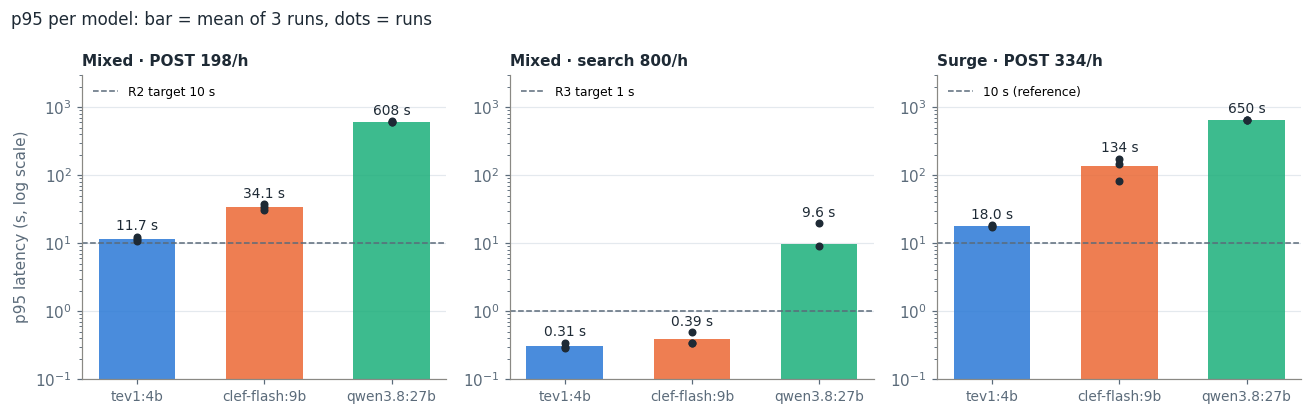

In [ ]:
panels = [("mixed", "POST /tickets", "Mixed · POST 198/h", 10, "R2 target 10 s"),
          ("mixed", "GET /search", "Mixed · search 800/h", 1, "R3 target 1 s"),
          ("surge", "POST /tickets", "Surge · POST 334/h", 10, "10 s (reference)")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (test, label, title, target, target_label) in zip(axes, panels):
    for i, tag in enumerate(MODELS.values()):
        g = per_run[(per_run.model == tag) & (per_run.test == test) & (per_run.endpoint == label)]
        if g.empty:
            continue
        ax.bar(i, g.p95.mean(), width=0.6, color=MODEL_COLORS[tag], alpha=0.85)
        ax.scatter([i] * len(g), g.p95, s=18, color=INK, zorder=3)
        ax.text(i, g.p95.max() * 1.25, fmt(g.p95.mean()) + " s", ha="center", fontsize=9, color=INK)
    ax.axhline(target, color=MUTED, linestyle="--", linewidth=1, label=target_label)
    ax.legend(loc="upper left", frameon=False, fontsize=8)
    ax.set_yscale("log")
    ax.set_ylim(0.1, 3000)
    ax.set_xticks(range(len(MODELS)), list(MODELS.values()), fontsize=9)
    ax.grid(axis="x", visible=False)
    ax.set_title(title, loc="left", fontweight="bold", fontsize=10, color=INK)
axes[0].set_ylabel("p95 latency (s, log scale)")
fig.suptitle("p95 per model: bar = mean of 3 runs, dots = runs", x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "p95_vs_targets.png"), bbox_inches="tight", facecolor="white")
plt.show()


## 6. Is the queue growing? Latency over the hour (surge, run 1)

Each dot is one ticket, placed at the minute it arrived. A flat band means the service keeps up; a rising
band means a queue is building faster than it drains.

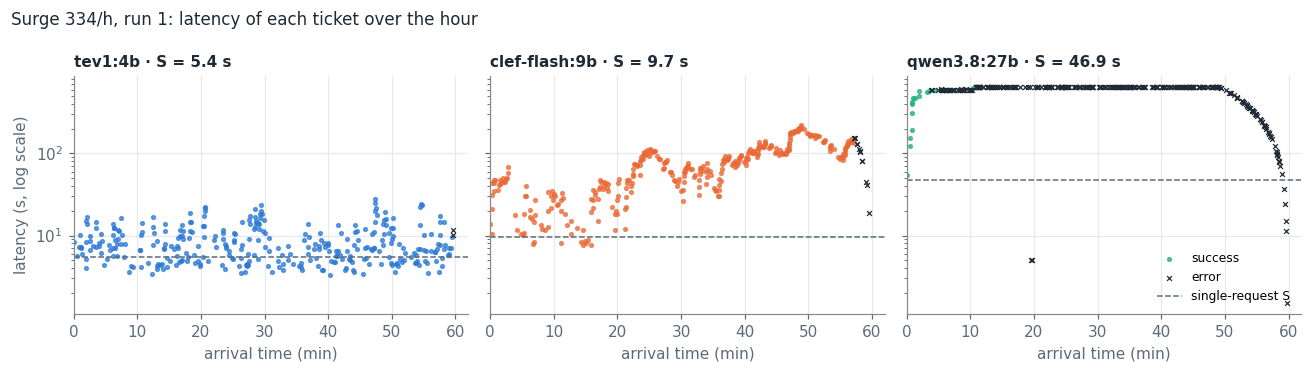

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, tag in zip(axes, MODELS.values()):
    r = runs.get((tag, "surge", 1))
    if r is None:
        continue
    g = r["jtl"][r["jtl"].label == "POST /tickets"]
    ax.scatter(g.t_min[g.ok], g.elapsed[g.ok] / 1000, s=6, color=MODEL_COLORS[tag], alpha=0.7, label="success")
    ax.scatter(g.t_min[~g.ok], g.elapsed[~g.ok] / 1000, s=10, marker="x", color=INK, linewidths=0.8, label="error")
    ax.axhline(S[tag], color=MUTED, linestyle="--", linewidth=1, label="single-request S")
    ax.set_yscale("log")
    ax.set_xlim(0, 62)
    ax.set_xlabel("arrival time (min)")
    ax.set_title(f"{tag} · S = {S[tag]:.1f} s", loc="left", fontweight="bold", fontsize=10, color=INK)
axes[0].set_ylabel("latency (s, log scale)")
axes[-1].legend(loc="lower right", frameon=False, fontsize=8)
fig.suptitle("Surge 334/h, run 1: latency of each ticket over the hour", x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "surge_latency_over_time.png"), bbox_inches="tight", facecolor="white")
plt.show()


## 7. Stress test: p95 latency per arrival-rate step (tev1:4b)

Each sample is assigned to the 15-minute step in which it **arrived**. A step is amber when completions
fall more than 5% below the offered rate, which means the service can no longer keep up.

In [ ]:
stress = runs.get(("tev1:4b", "stress", 1))
jtl = stress["jtl"]
steps = [(int(r), int(m)) for r, m in
         re.findall(r"rate\((\d+)/hour\) random_arrivals\((\d+) min\)", stress["loadgen"]["post_schedule"])]

t0 = jtl.timeStamp.min()
rows, start = [], t0
for rate, minutes in steps:
    end = start + minutes * 60_000
    arrived = jtl[(jtl.timeStamp >= start) & (jtl.timeStamp < end)]
    completed = jtl[jtl.ok & (jtl.end >= start) & (jtl.end < end)]
    lat = (arrived.elapsed / 1000).tolist()
    per_hour = 60 / minutes
    rows.append({"step": f"{rate}/h", "offered /h": len(arrived) * per_hour, "completed /h": len(completed) * per_hour,
                 "p50 (s)": nearest_rank(lat, 50), "p95 (s)": nearest_rank(lat, 95), "p99 (s)": nearest_rank(lat, 99),
                 "max (s)": max(lat), "errors %": 100 * (1 - arrived.ok.mean())})
    start = end
stress_steps = pd.DataFrame(rows)
stress_steps["keeps up"] = stress_steps["completed /h"] >= 0.95 * stress_steps["offered /h"]

saturated = stress_steps[~stress_steps["keeps up"]]
limit_lo, limit_hi = saturated["completed /h"].min(), saturated["completed /h"].max()
print(f"Limit: completions plateau at {limit_lo:.0f}-{limit_hi:.0f}/h once offered >= {saturated['offered /h'].min():.0f}/h; "
      f"1/S = {3600 / S['tev1:4b']:.0f}/h; predicted {PREDICTED_CEILING}/h")
stress_steps.round(1)


Limit: completions plateau at 628-644/h once offered >= 796/h; 1/S = 665/h; predicted 465/h


,step,offered /h,completed /h,p50 (s),p95 (s),p99 (s),max (s),errors %,keeps up
0,400/h,412.0,408.0,7.6,15.5,18.7,21.5,0.0,True
1,600/h,600.0,592.0,15.2,33.5,40.3,42.9,0.0,True
2,800/h,796.0,644.0,142.7,230.6,243.9,244.9,0.0,False
3,1000/h,992.0,628.0,333.6,464.0,484.4,485.3,53.2,False


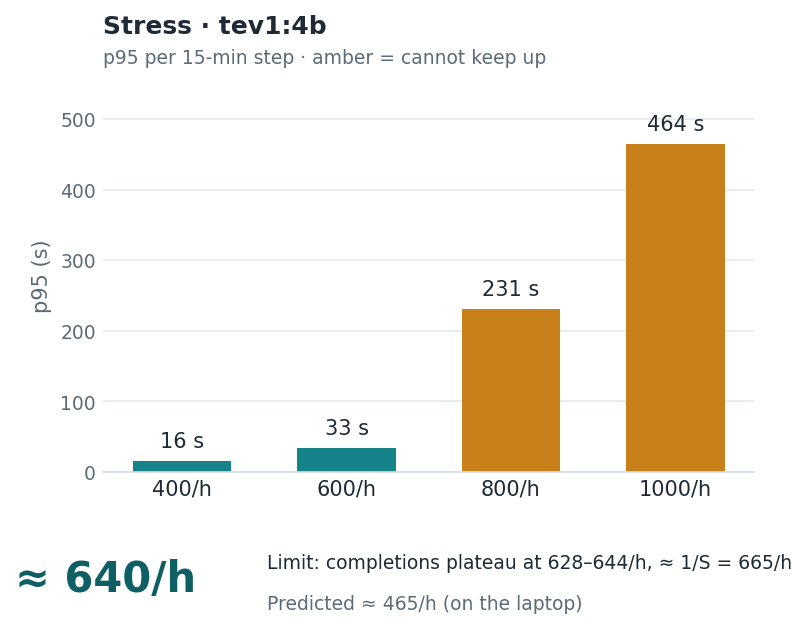

In [ ]:
fig, ax = plt.subplots(figsize=(5.6, 3.4), dpi=150)
colors = [TEAL if ok else AMBER for ok in stress_steps["keeps up"]]
bars = ax.bar(stress_steps["step"], stress_steps["p95 (s)"], width=0.6, color=colors)
top = stress_steps["p95 (s)"].max()
for bar, v in zip(bars, stress_steps["p95 (s)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + top * 0.03, f"{v:.0f} s", ha="center", va="bottom", fontsize=10, color=INK)
ax.set_ylabel("p95 (s)", color=MUTED)
ax.set_ylim(0, top * 1.2)
ax.grid(axis="x", visible=False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#D5DEE5")
ax.tick_params(axis="x", colors=INK, labelsize=10, length=0)
ax.tick_params(axis="y", labelsize=9, length=0)
ax.set_title("Stress · tev1:4b", loc="left", fontsize=12, fontweight="bold", color=INK, pad=22)
ax.text(0, 1.04, "p95 per 15-min step · amber = cannot keep up", transform=ax.transAxes, fontsize=9, color=MUTED)
fig.text(0.02, -0.06, f"≈ {round(limit_hi, -1):.0f}/h", fontsize=20, fontweight="bold", color="#0E5F64", va="top")
fig.text(0.32, -0.05, f"Limit: completions plateau at {limit_lo:.0f}–{limit_hi:.0f}/h, ≈ 1/S = {3600 / S['tev1:4b']:.0f}/h",
         fontsize=9, color=INK, va="top")
fig.text(0.32, -0.13, f"Predicted ≈ {PREDICTED_CEILING}/h (on the laptop)", fontsize=9, color=MUTED, va="top")
fig.savefig(os.path.join(OUT_DIR, "stress_tev1-4b.png"), bbox_inches="tight", facecolor="white")
plt.show()


## 8. Bottleneck evidence

Checked against the prediction record (B1 to B4):

- **Ollama share of latency** (B1, predicted ≥ 95%): Ollama's own `total_duration` over the service's
  `latency_ms`. Only `/api/chat` (qwen) reports durations; `/v1/systemone` returns token counts only.
- **Host CPU** (B1, predicted ≥ 90%): mean total CPU over the run from `cpu.csv`. The `Process(ollama)`
  counter stays near 0% because inference runs in Ollama's separate runner process, so the total is used.
- **Queue wait** (B2): median service `latency_ms` minus the single-request p50 from the accuracy run.
- **Network** (B4, predicted median ≤ 150 ms): JMeter `elapsed` minus the service's `latency_ms`, matched by
  request id, for successful requests only.

In [ ]:
single_p50 = service_time.set_index("model")["p50 (s)"]
rows = []
for (tag, test, run), r in runs.items():
    if test == "stress":
        continue
    jtl, log = r["jtl"], r["log"]
    posts = log[(log.path == "/tickets") & log.request_id.str.startswith("t-")]
    ok_posts = posts[posts.status == 200]
    m = jtl[jtl.ok].merge(log[["request_id", "latency_ms"]], left_on="req_id", right_on="request_id")
    net = m.elapsed - m.latency_ms
    share = np.nan
    if "ollama_total_duration_ns" in ok_posts and ok_posts.ollama_total_duration_ns.notna().any():
        share = (ok_posts.ollama_total_duration_ns / 1e6 / ok_posts.latency_ms).median()
    lam = 198 if test == "mixed" else 334
    rows.append({
        "model": tag, "test": test, "run": run, "ρ = λS": lam * S[tag] / 3600,
        "Ollama share": share, "host CPU %": r["cpu"].total.mean(), "ollama process CPU %": r["cpu"].ollama_process.mean(),
        "service p50 (s)": ok_posts.latency_ms.median() / 1000,
        "queue wait p50 (s)": ok_posts.latency_ms.median() / 1000 - single_p50[tag],
        "network median (ms)": net.median(), "network p95 (ms)": nearest_rank(net, 95),
    })
bottleneck = pd.DataFrame(rows)
bottleneck.groupby(["model", "test"]).mean(numeric_only=True).drop(columns="run").round(2)


ρ = λS  Ollama share  host CPU %  ollama process CPU %  \
model         test                                                            
clef-flash:9b mixed    0.53           NaN       27.51                  0.12   
              surge    0.90           NaN       47.78                  0.24   
qwen3.8:27b   mixed    2.58          1.00       60.80                  0.17   
              surge    4.35          0.81       58.77                  0.20   
tev1:4b       mixed    0.30           NaN       20.96                  0.10   
              surge    0.50           NaN       25.08                  0.18   

                     service p50 (s)  queue wait p50 (s)  network median (ms)  \
model         test                                                              
clef-flash:9b mixed            13.91                4.42               204.44   
              surge            45.78               36.29                79.54   
qwen3.8:27b   mixed           564.64              523.10                26.73   
              surge           707.09              665.54                98.62   
tev1:4b       mixed             5.50                0.17               187.59   
              surge             6.89                1.57               234.85   

                     network p95 (ms)  
model         test                     
clef-flash:9b mixed            388.18  
              surge            244.94  
qwen3.8:27b   mixed             61.27  
              surge            370.25  
tev1:4b       mixed            319.19  
              surge            380.79

### Searches queue behind classification (B3)

For every search in the mixed runs: how many `POST /tickets` were in flight when it started. Once more than
40 POSTs are in flight, FastAPI's worker threads are all busy waiting on Ollama, and a search has to wait
for one even though it never touches the model.

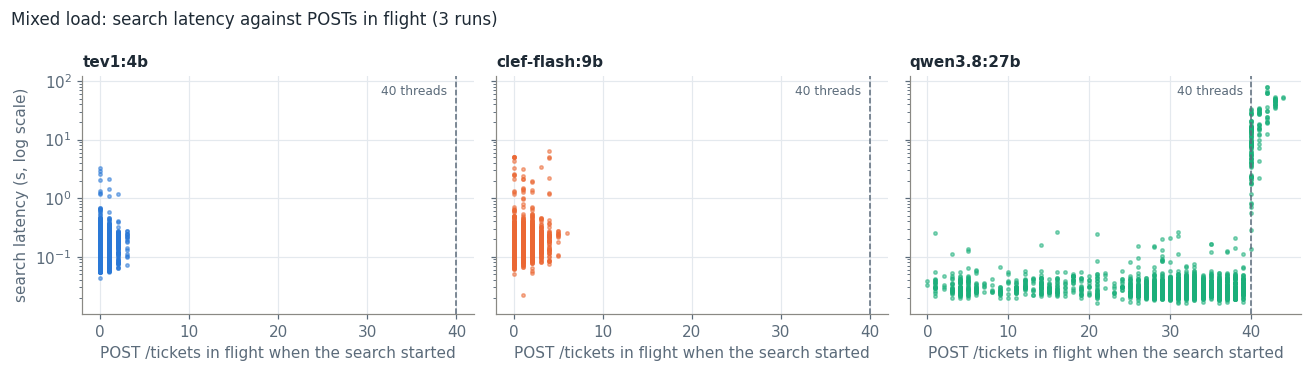

,model,run,searches,with ≥ 40 POSTs in flight,"search p95 (s), pool free","search p95 (s), pool full"
0,tev1:4b,1,800,0,0.29,NaN
1,tev1:4b,2,800,0,0.30,NaN
2,tev1:4b,3,800,0,0.35,NaN
3,clef-flash:9b,1,800,0,0.34,NaN
4,clef-flash:9b,2,800,0,0.34,NaN
5,clef-flash:9b,3,800,0,0.49,NaN
6,qwen3.8:27b,1,800,71,0.05,29.72
7,qwen3.8:27b,2,800,21,0.05,15.49
8,qwen3.8:27b,3,800,59,0.04,66.44


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
rows = []
for ax, tag in zip(axes, MODELS.values()):
    for run in (1, 2, 3):
        r = runs.get((tag, "mixed", run))
        if r is None:
            continue
        jtl = r["jtl"]
        post = jtl[jtl.label == "POST /tickets"]
        search = jtl[jtl.label == "GET /search"]
        starts, ends = np.sort(post.timeStamp.values), np.sort(post.end.values)
        in_flight = np.searchsorted(starts, search.timeStamp.values, side="right") - \
            np.searchsorted(ends, search.timeStamp.values, side="right")
        ax.scatter(in_flight, search.elapsed / 1000, s=5, alpha=0.5, color=MODEL_COLORS[tag])
        busy = in_flight >= THREAD_POOL
        rows.append({"model": tag, "run": run, "searches": len(search), f"with ≥ {THREAD_POOL} POSTs in flight": int(busy.sum()),
                     "search p95 (s), pool free": nearest_rank(search.elapsed[~busy] / 1000, 95),
                     "search p95 (s), pool full": nearest_rank(search.elapsed[busy] / 1000, 95)})
    ax.axvline(THREAD_POOL, color=MUTED, linestyle="--", linewidth=1)
    ax.text(THREAD_POOL - 1, 0.92, f"{THREAD_POOL} threads", transform=ax.get_xaxis_transform(),
            ha="right", fontsize=8, color=MUTED)
    ax.set_yscale("log")
    ax.set_xlabel("POST /tickets in flight when the search started")
    ax.set_title(tag, loc="left", fontweight="bold", fontsize=10, color=INK)
axes[0].set_ylabel("search latency (s, log scale)")
fig.suptitle("Mixed load: search latency against POSTs in flight (3 runs)", x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "search_vs_in_flight.png"), bbox_inches="tight", facecolor="white")
plt.show()
search_starvation = pd.DataFrame(rows)
search_starvation.round(2)


## 9. Save

Tables go to `loadtest/analysis_output/` next to the charts above.

In [ ]:
for name, df in {"service_time": service_time, "inventory": inventory, "per_run": per_run, "errors": errors,
                 "summary": summary, "stress_steps": stress_steps, "bottleneck": bottleneck,
                 "search_starvation": search_starvation}.items():
    df.to_csv(os.path.join(OUT_DIR, f"{name}.csv"), index=False)
print("Saved to", os.path.relpath(OUT_DIR, ROOT))
display(Markdown("**Requirement verdicts**"))
summary[["model", "test", "requirement", "runs passing"]]


Saved to loadtest\analysis_output


**Requirement verdicts**

,model,test,requirement,runs passing
0,tev1:4b,Mixed · POST 198/h,R2 FAIL,0/3
1,tev1:4b,Mixed · search 800/h,R3 PASS,3/3
2,tev1:4b,Surge · POST 334/h,R1 FAIL,2/3
3,clef-flash:9b,Mixed · POST 198/h,R2 FAIL,0/3
4,clef-flash:9b,Mixed · search 800/h,R3 PASS,3/3
5,clef-flash:9b,Surge · POST 334/h,R1 FAIL,0/3
6,qwen3.8:27b,Mixed · POST 198/h,R2 FAIL,0/3
7,qwen3.8:27b,Mixed · search 800/h,R3 FAIL,1/3
8,qwen3.8:27b,Surge · POST 334/h,R1 FAIL,0/3
